
# Evaluation — Multi-run Leaderboard & BM25 Variant Plots (no bootstrap)

This notebook supports three modes:

1. **GLOBAL** — Compare across all methods but **only** the canonical BM25 runs (`bm25_unigram`, `bm25_unibigram`).
2. **LEXICAL** - Compare across all **lexical** methods but only canonical BM25 runs
3. **BM25_VARIANTS** — Focused evaluation of **all variants** for a chosen BM25 family (e.g., every `bm25_unigram_*` run).
4. **DENSE* - Compare across all **dense** methods (file name: "dense_*")

Artifacts expected from previous steps:
- Each run folder under `/work/runs/<method>/` contains `metrics_dual.json` written by the per-method evaluator.  
- This structure is produced by your retrieval → metrics workflow.



## Config
- `EVAL_MODE`: `"GLOBAL"` or `"LEXICAL"` or `DENSE` or `"BM25_VARIANTS"`  
- If `BM25_VARIANTS`, set `BM25_FAMILY` to `"bm25_unigram"` or `"bm25_unibigram"`.


In [35]:
from pathlib import Path
import json, os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Paths ---
RUNS_ROOT = Path("/work/runs")
EVAL_OUT  = Path("/work/eval") # eval, eval/bm25_unigram,  eval/bm25_unibigram
EVAL_OUT.mkdir(parents=True, exist_ok=True)

# --- Mode ---
EVAL_MODE    = "DENSE"          # "GLOBAL" | "BM25_VARIANTS" / "LEXICAL" / "DENSE"
BM25_FAMILY  = "prf_"    # only used when EVAL_MODE == "BM25_VARIANTS": "bm25_unigram_params" 
ALLOWED_BM25 = {"bm25_unigram", "bm25_unibigram", "bm25_unigram_params"}  # only these among BM25 in GLOBAL mode

print("RUNS_ROOT:", RUNS_ROOT)
print("EVAL_OUT :", EVAL_OUT)
print("EVAL_MODE:", EVAL_MODE, "| BM25_FAMILY:", BM25_FAMILY)
print("ALLOWED_BM25:", ALLOWED_BM25)


RUNS_ROOT: /work/runs
EVAL_OUT : /work/eval
EVAL_MODE: DENSE | BM25_FAMILY: prf_
ALLOWED_BM25: {'bm25_unibigram', 'bm25_unigram', 'bm25_unigram_params'}



## Discovery helpers
We scan `/work/runs/<method>/metrics_dual.json`.

- **GLOBAL**: include everything except BM25 sweeps; only `bm25_unigram` & `bm25_unibigram`.
- **LEXICAL** lexical indexes execpt BM25 sweeps
- **DENSE** dense indexes
- **BGE** bge indexes
- **BM25_VARIANTS**: include **all** methods whose folder starts with `BM25_FAMILY`.


In [36]:
def _metrics_dual_path(run_dir: Path) -> Path:
    return run_dir / "metrics_dual.json"

def _is_excluded(method_name: str) -> bool:
    """Exclude any methods we don't want globally (like prf*)"""
    return method_name.lower().startswith("prf")

def _is_selected_bm25(method_name: str, allowed_set) -> bool:
    return method_name.lower() in {m.lower() for m in allowed_set}

def _is_dense(method_name: str) -> bool:
    """Dense methods are named 'dense_*' or 'bge_*'"""
    name = method_name.lower()
    return name.startswith("dense_") or name.startswith("bge_")

def _is_bge(method_name: str) -> bool:
    """BGE methods are named 'bge_*'"""
    return method_name.lower().startswith("bge")

def _should_include_global(method_name: str, allowed_bm25) -> bool:
    name = method_name.lower()
    if name.startswith("bm25"):
        return _is_selected_bm25(name, allowed_bm25)
    return True  # include non-BM25 by default

def _should_include_bm25_variants(method_name: str, family: str) -> bool:
    return method_name.lower().startswith(family.lower())

def discover_runs(runs_root: Path, mode: str, allowed_bm25, family: str) -> dict:
    runs = {}
    if not runs_root.exists():
        return runs
    for sub in runs_root.iterdir():
        if not sub.is_dir():
            continue
        method = sub.name  # /work/runs/<method>
        md = _metrics_dual_path(sub)
        if not md.exists():
            continue

        # --- Exclude unwanted methods ---
        #if _is_excluded(method):
            #continue
            
        if mode == "GLOBAL":
            if _should_include_global(method, allowed_bm25):
                runs[method] = sub
        elif mode =="BM25_VARIANTS":
            if _should_include_bm25_variants(method, family):
                runs[method] = sub
        elif mode == "LEXICAL":
            if _should_include_global(method, allowed_bm25) and not _is_dense(method) and not _is_bge(method):
                runs[method] = sub
        elif mode == "DENSE":
            if _is_dense(method):
                runs[method] = sub
    return dict(sorted(runs.items()))

runs = discover_runs(RUNS_ROOT, EVAL_MODE, ALLOWED_BM25, BM25_FAMILY)
print(f"Selected runs ({len(runs)}):")
for k,v in runs.items():
    print(" -", k, "->", v)


Selected runs (7):
 - bge_m3_colbert -> /work/runs/bge_m3_colbert
 - bge_m3_dense -> /work/runs/bge_m3_dense
 - bge_m3_sparse -> /work/runs/bge_m3_sparse
 - dense_e5 -> /work/runs/dense_e5
 - dense_es_hiiamsid -> /work/runs/dense_es_hiiamsid
 - dense_gte -> /work/runs/dense_gte
 - dense_gte_instrQ -> /work/runs/dense_gte_instrQ



## Load metrics
Use the `metrics_dual.json` file saved by the per-method evaluation to build a unified dataframe.


In [37]:

def load_metrics_dual(method: str, run_dir: Path) -> pd.DataFrame:
    p = run_dir / "metrics_dual.json"
    with open(p, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    # Ensure standard columns
    std_cols = ["method","target","scope","queries","Acc@1","Recall@5","Recall@10","MRR","nDCG@10"]
    if "method" not in df.columns:
        df["method"] = method
    for col in std_cols:
        if col not in df.columns:
            df[col] = None
    df = df[std_cols]
    # Sort for display
    order = {"overall":0, "has_numbers":1, "no_numbers":2}
    df["__scope_order__"] = df["scope"].map(order).fillna(99)
    df = df.sort_values(["target","__scope_order__","method"]).drop(columns="__scope_order__")
    return df

frames = []
for m, p in runs.items():
    try:
        frames.append(load_metrics_dual(m, p))
    except Exception as e:
        print(f"[WARN] Failed to load {m}: {e}")

if frames:
    df_metrics = pd.concat(frames, ignore_index=True)
else:
    df_metrics = pd.DataFrame(columns=["method","target","scope","queries","Acc@1","Recall@5","Recall@10","MRR","nDCG@10"])

print("Loaded rows:", len(df_metrics))
display(df_metrics.head(10))

# Save the raw merged table
suffix = "global" if EVAL_MODE=="GLOBAL" else f"variants_{BM25_FAMILY}"
df_metrics.to_csv(EVAL_OUT / f"all_metrics_dual_merged__{suffix}.csv", index=False)
df_metrics.to_json(EVAL_OUT / f"all_metrics_dual_merged__{suffix}.json", orient="records", indent=2, force_ascii=False)
print("Saved merged metrics to", EVAL_OUT)


Loaded rows: 42


,method,target,scope,queries,Acc@1,Recall@5,Recall@10,MRR,nDCG@10
0,bge_m3_colbert,item,overall,16590.0,0.447981,0.753285,0.784750,0.579611,0.630219
1,bge_m3_colbert,item,has_numbers,16561.0,0.447437,0.752853,0.784373,0.579086,0.629727
2,bge_m3_colbert,item,no_numbers,29.0,0.758621,1.000000,1.000000,0.879310,0.910914
3,bge_m3_colbert,parent,overall,16590.0,0.996624,0.999397,0.999638,0.997685,0.957519
4,bge_m3_colbert,parent,has_numbers,16561.0,0.996619,0.999396,0.999638,0.997681,0.957445
5,bge_m3_colbert,parent,no_numbers,29.0,1.000000,1.000000,1.000000,1.000000,1.000000
6,bge_m3_dense,item,overall,16590.0,0.126884,0.348764,0.464256,0.233254,0.278323
7,bge_m3_dense,item,has_numbers,16561.0,0.125777,0.347624,0.463317,0.232123,0.277216
8,bge_m3_dense,item,no_numbers,29.0,0.758621,1.000000,1.000000,0.879310,0.910914
9,bge_m3_dense,parent,overall,16590.0,0.960398,0.984207,0.993369,0.970720,0.906110


Saved merged metrics to /work/eval



## Leaderboard tables (Overall)
Paper-ready tables summarizing item- and parent-level metrics for the **Overall** scope.


In [38]:

def leaderboard(df: pd.DataFrame, target: str) -> pd.DataFrame:
    d = (df[(df["target"]==target) & (df["scope"].str.lower()=="overall")]
          .copy())
    cols = ["method","queries","Acc@1","Recall@5","Recall@10","MRR","nDCG@10"]
    d = d[cols].sort_values(["Acc@1","MRR","nDCG@10"], ascending=False).reset_index(drop=True)
    return d

lb_item   = leaderboard(df_metrics, target="item")
lb_parent = leaderboard(df_metrics, target="parent")

print("Item-level leaderboard (Overall)")
display(lb_item.style.format({"Acc@1":"{:.3f}","Recall@5":"{:.3f}","Recall@10":"{:.3f}","MRR":"{:.3f}","nDCG@10":"{:.3f}"}))
print("Parent-level leaderboard (Overall)")
display(lb_parent.style.format({"Acc@1":"{:.3f}","Recall@5":"{:.3f}","Recall@10":"{:.3f}","MRR":"{:.3f}","nDCG@10":"{:.3f}"}))

# Save
suffix = "global" if EVAL_MODE=="GLOBAL" else f"variants_{BM25_FAMILY}"
lb_item.to_csv(EVAL_OUT / f"leaderboard_item_overall__{suffix}.csv", index=False)
lb_parent.to_csv(EVAL_OUT / f"leaderboard_parent_overall__{suffix}.csv", index=False)


Item-level leaderboard (Overall)


,method,queries,Acc@1,Recall@5,Recall@10,MRR,nDCG@10
0,bge_m3_colbert,16590.000000,0.448,0.753,0.785,0.580,0.630
1,dense_e5,16589.000000,0.134,0.376,0.518,0.251,0.303
2,bge_m3_dense,16590.000000,0.127,0.349,0.464,0.233,0.278
3,bge_m3_sparse,16590.000000,0.125,0.401,0.535,0.252,0.309
4,dense_es_hiiamsid,16589.000000,0.024,0.093,0.144,0.063,0.075
5,dense_gte_instrQ,16590.000000,0.014,0.049,0.074,0.034,0.040
6,dense_gte,16589.000000,0.013,0.044,0.066,0.030,0.036


Parent-level leaderboard (Overall)


,method,queries,Acc@1,Recall@5,Recall@10,MRR,nDCG@10
0,bge_m3_colbert,16590.000000,0.997,0.999,1.000,0.998,0.958
1,bge_m3_sparse,16590.000000,0.994,0.999,1.000,0.996,0.983
2,dense_e5,16589.000000,0.982,0.993,0.996,0.987,0.969
3,bge_m3_dense,16590.000000,0.960,0.984,0.993,0.971,0.906
4,dense_gte,16589.000000,0.837,0.941,0.961,0.884,0.701
5,dense_gte_instrQ,16590.000000,0.697,0.938,0.978,0.798,0.651
6,dense_es_hiiamsid,16589.000000,0.395,0.532,0.598,0.461,0.389



## Numeric vs non-numeric splits (Item-level)
We pivot the **item-level** metrics to compare *Has numbers* vs *No numbers* across methods.


In [39]:

def numeric_split_table(df: pd.DataFrame, metric: str = "Acc@1") -> pd.DataFrame:
    d = df[(df["target"]=="item") & (df["scope"].isin(["has_numbers","no_numbers"]))].copy()
    d["scope"] = d["scope"].replace({"has_numbers":"Has numbers", "no_numbers":"No numbers"})
    pivot = d.pivot_table(index="method", columns="scope", values=metric, aggfunc="first")
    # Align to leaderboard order if not empty
    order = lb_item["method"] if not lb_item.empty else pivot.index
    pivot = pivot.reindex(order)
    return pivot

tbl_acc1 = numeric_split_table(df_metrics, "Acc@1")
tbl_recall10 = numeric_split_table(df_metrics, "Recall@10")
display(tbl_acc1.style.format("{:.3f}").set_caption("Item-level Acc@1 — Numeric vs No-numeric"))
display(tbl_recall10.style.format("{:.3f}").set_caption("Item-level Recall@10 — Numeric vs No-numeric"))

suffix = "global" if EVAL_MODE=="GLOBAL" else f"variants_{BM25_FAMILY}"
tbl_acc1.to_csv(EVAL_OUT / f"numeric_split_item_acc1__{suffix}.csv")
tbl_recall10.to_csv(EVAL_OUT / f"numeric_split_item_recall10__{suffix}.csv")


scope,Has numbers,No numbers
method,,
bge_m3_colbert,0.447,0.759
dense_e5,0.133,0.875
bge_m3_dense,0.126,0.759
bge_m3_sparse,0.124,0.655
dense_es_hiiamsid,0.024,0.438
dense_gte_instrQ,0.013,0.379
dense_gte,0.013,0.094


scope,Has numbers,No numbers
method,,
bge_m3_colbert,0.784,1.000
dense_e5,0.517,1.000
bge_m3_dense,0.463,1.000
bge_m3_sparse,0.535,1.000
dense_es_hiiamsid,0.142,0.969
dense_gte_instrQ,0.073,0.897
dense_gte,0.065,0.562



## Plots (paper-ready)
Matplotlib only, one figure per plot, no explicit colors or styles.


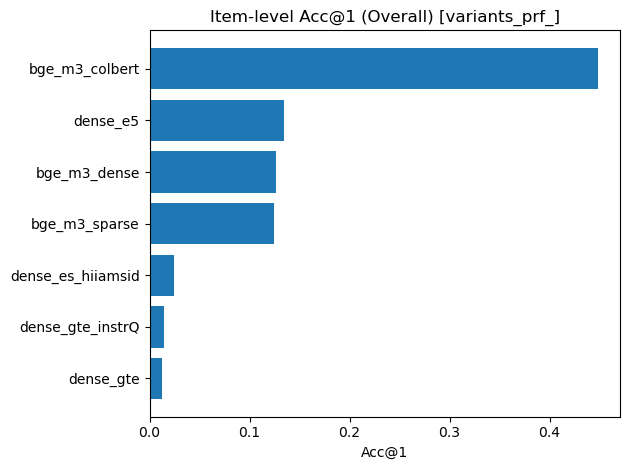

Saved plot: /work/eval/plot_item_acc1__variants_prf_.png


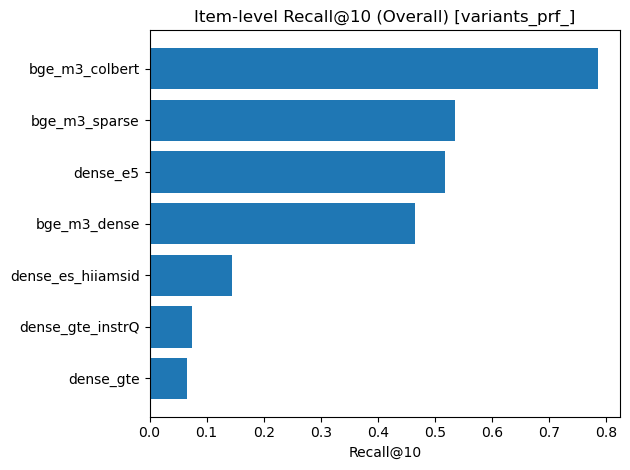

Saved plot: /work/eval/plot_item_recall10__variants_prf_.png


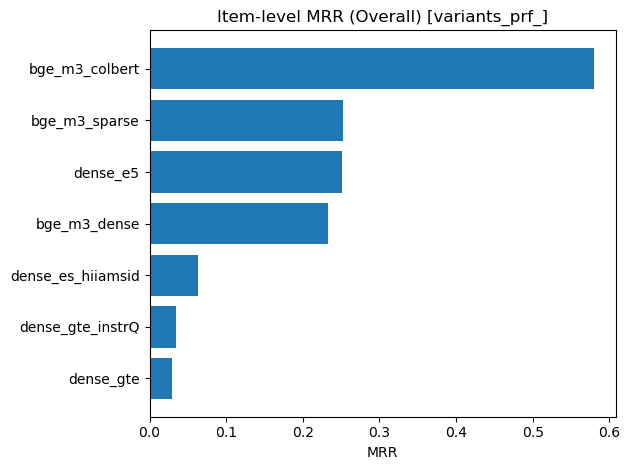

Saved plot: /work/eval/plot_item_mrr__variants_prf_.png


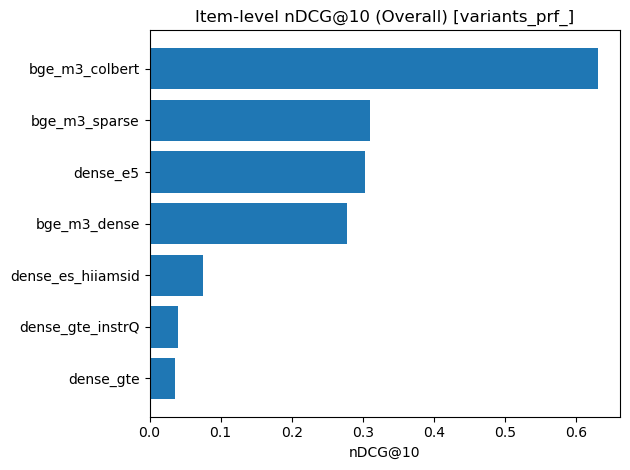

Saved plot: /work/eval/plot_item_ndcg10__variants_prf_.png


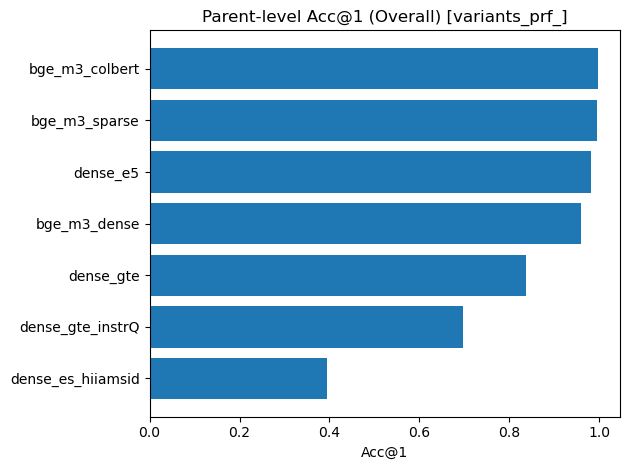

Saved plot: /work/eval/plot_parent_acc1__variants_prf_.png


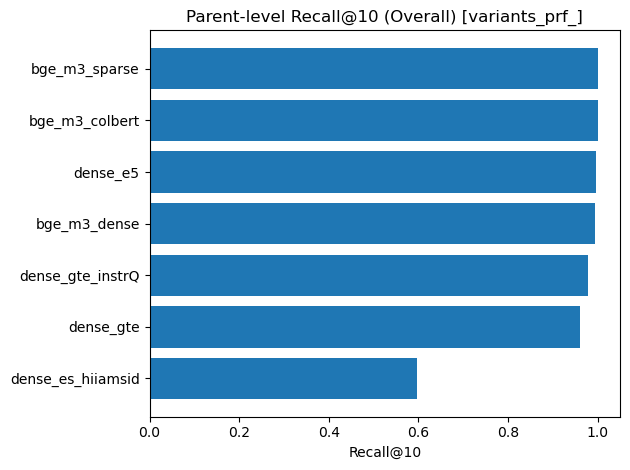

Saved plot: /work/eval/plot_parent_recall10__variants_prf_.png


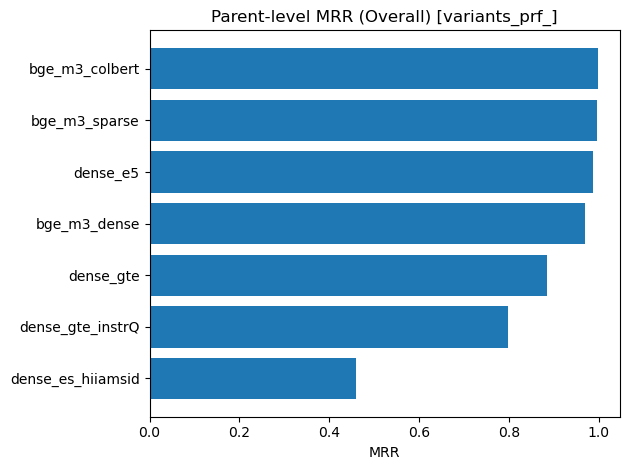

Saved plot: /work/eval/plot_parent_mrr__variants_prf_.png


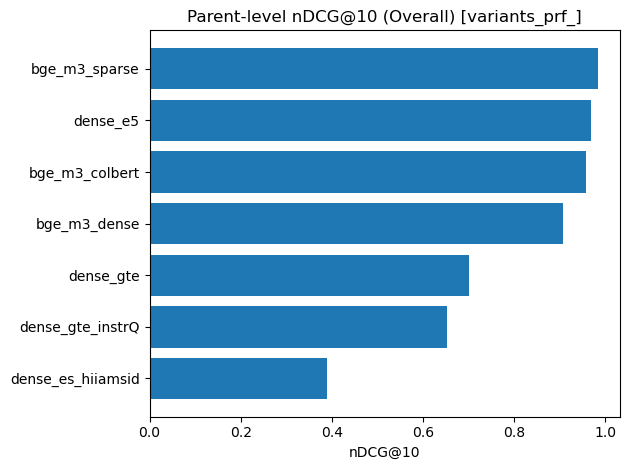

Saved plot: /work/eval/plot_parent_ndcg10__variants_prf_.png


In [40]:

def barplot_metric(df: pd.DataFrame, target: str, metric: str, title: str, out_name: str):
    d = df[(df["target"]==target) & (df["scope"].str.lower()=="overall")].copy()
    d = d.sort_values(metric, ascending=False)
    plt.figure()
    plt.barh(d["method"], d[metric])
    plt.gca().invert_yaxis()
    plt.xlabel(metric)
    plt.title(title)
    plt.tight_layout()
    out_path = EVAL_OUT / out_name
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved plot:", out_path)

suffix = "global" if EVAL_MODE=="GLOBAL" else f"variants_{BM25_FAMILY}"
barplot_metric(df_metrics, "item", "Acc@1",     f"Item-level Acc@1 (Overall) [{suffix}]",   f"plot_item_acc1__{suffix}.png")
barplot_metric(df_metrics, "item", "Recall@10", f"Item-level Recall@10 (Overall) [{suffix}]", f"plot_item_recall10__{suffix}.png")
barplot_metric(df_metrics, "item", "MRR",       f"Item-level MRR (Overall) [{suffix}]",     f"plot_item_mrr__{suffix}.png")
barplot_metric(df_metrics, "item", "nDCG@10",   f"Item-level nDCG@10 (Overall) [{suffix}]", f"plot_item_ndcg10__{suffix}.png")

barplot_metric(df_metrics, "parent", "Acc@1",     f"Parent-level Acc@1 (Overall) [{suffix}]",   f"plot_parent_acc1__{suffix}.png")
barplot_metric(df_metrics, "parent", "Recall@10", f"Parent-level Recall@10 (Overall) [{suffix}]", f"plot_parent_recall10__{suffix}.png")
barplot_metric(df_metrics, "parent", "MRR",       f"Parent-level MRR (Overall) [{suffix}]",     f"plot_parent_mrr__{suffix}.png")
barplot_metric(df_metrics, "parent", "nDCG@10",   f"Parent-level nDCG@10 (Overall) [{suffix}]", f"plot_parent_ndcg10__{suffix}.png")



## BM25 variant parsing & parameter plots (used in BM25_VARIANTS mode)
Method names that encode parameters (e.g., `bm25_unigram_k1_1.2_b_0.75` or `bm25_unibigram-k1-0.9-b-0.4`) are parsed to `(k1, b)`.


In [41]:

def parse_k1_b(method_name: str):
    """Extract k1 and b from method name if present.
    Examples (case-insensitive): 'bm25_unigram_k1_1.2_b_0.75', 'bm25_unibigram-k1-0.9-b-0.4'.
    Returns (k1: float|None, b: float|None).
    """
    name = method_name.lower()
    # Try k1... and b... patterns (underscore or dash separators)
    m = re.search(r'k1[\-_]?([0-9]+(?:\.[0-9]+)?)', name)
    n = re.search(r'(^|[^a-z])b[\-_]?([0-9]+(?:\.[0-9]+)?)', name)
    k1 = float(m.group(1)) if m else None
    b  = float(n.group(2)) if n else None
    return k1, b

def build_bm25_param_table(df: pd.DataFrame) -> pd.DataFrame:
    # Item-level Overall only
    d = df[(df["target"]=="item") & (df["scope"].str.lower()=="overall")].copy()
    d[["k1","b"]] = d["method"].apply(lambda s: pd.Series(parse_k1_b(s)))
    return d

if EVAL_MODE == "BM25_VARIANTS":
    param_df = build_bm25_param_table(df_metrics)
    display(param_df.head(10))

    # Table sorted by Acc@1
    best = param_df.sort_values("Acc@1", ascending=False)
    display(best[["method","k1","b","Acc@1","Recall@10","MRR","nDCG@10"]].head(20))
    best.to_csv(EVAL_OUT / f"bm25_{BM25_FAMILY}_variants_ranked.csv", index=False)

    # Scatter: Acc@1 vs k1 (marker size ~ b)
    if param_df["k1"].notna().any():
        plt.figure()
        x = param_df["k1"]
        y = param_df["Acc@1"]
        sizes = (param_df["b"].fillna(param_df["b"].median() if param_df["b"].notna().any() else 0.5) + 0.01) * 300
        plt.scatter(x, y, s=sizes)
        for _, r in param_df.iterrows():
            if pd.notna(r["k1"]) and pd.notna(r["Acc@1"]):
                plt.annotate(r["method"], (r["k1"], r["Acc@1"]))
        plt.xlabel("k1")
        plt.ylabel("Acc@1 (item)")
        plt.title(f"{BM25_FAMILY}: Acc@1 vs k1 (marker size ~ b)")
        plt.tight_layout()
        out_path = EVAL_OUT / f"bm25_{BM25_FAMILY}_acc1_vs_k1.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved plot:", out_path)

    # If both k1 & b present, grid-like scatter
    both = param_df[param_df["k1"].notna() & param_df["b"].notna()].copy()
    if not both.empty:
        plt.figure()
        plt.scatter(both["k1"], both["b"])
        for _, r in both.iterrows():
            plt.annotate(f"{r['Acc@1']:.3f}", (r["k1"], r["b"]))
        plt.xlabel("k1")
        plt.ylabel("b")
        plt.title(f"{BM25_FAMILY}: param grid (label=Acc@1)")
        plt.tight_layout()
        out_path = EVAL_OUT / f"bm25_{BM25_FAMILY}_param_grid_acc1.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved plot:", out_path)



## Optional: Latency vs accuracy (if available)
If a `latency.json` exists per run with fields like `mean_ms` or `p95_ms`, this cell will plot latency vs Acc@1.


In [42]:

def read_latency(run_dir: Path):
    p = run_dir / "latency.json"
    if p.exists():
        try:
            return json.load(open(p,"r",encoding="utf-8"))
        except Exception as e:
            print("[WARN] bad latency.json in", run_dir, e)
    return None

# Build a small table if present
lat_rows = []
for m, p in runs.items():
    lat = read_latency(p)
    if isinstance(lat, dict):
        lat_rows.append({"method": m,
                         "mean_ms": lat.get("mean_ms"),
                         "p95_ms": lat.get("p95_ms")})
df_latency = pd.DataFrame(lat_rows)
display(df_latency)

# Plot if both latency and metrics exist
if not df_latency.empty:
    # Merge with item Acc@1
    acc = df_metrics[(df_metrics["target"]=="item") & (df_metrics["scope"].str.lower()=="overall")][["method","Acc@1"]]
    d = df_latency.merge(acc, on="method", how="inner")
    if not d.empty:
        plt.figure()
        plt.scatter(d["mean_ms"], d["Acc@1"])
        for _, r in d.iterrows():
            plt.annotate(r["method"], (r["mean_ms"], r["Acc@1"]))
        plt.xlabel("Mean latency (ms)")
        plt.ylabel("Acc@1 (item)")
        plt.title("Latency vs Accuracy")
        plt.tight_layout()
        suffix = "global" if EVAL_MODE=="GLOBAL" else f"variants_{BM25_FAMILY}"
        out_path = EVAL_OUT / f"plot_latency_vs_acc1__{suffix}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved plot:", out_path)


""



## Saved artifacts
- `all_metrics_dual_merged__{global|variants_family}.(csv|json)` — merged per-run metrics.  
- `leaderboard_*_overall__{global|variants_family}.csv` — item/parent leaderboards.  
- `numeric_split_item_*__{global|variants_family}.csv` — numeric/no-numeric pivots.  
- `plot_*.png` — bar charts for paper figures.  
- **BM25_VARIANTS only**: `bm25_{family}_variants_ranked.csv`, `acc1_vs_k1`, `param_grid_acc1` plots.


In [43]:
# Save tables as latex

from pathlib import Path
import pandas as pd

def _normalize_df_for_export(df: pd.DataFrame, index_policy: str = "auto") -> pd.DataFrame:
    """
    Ensure the index isn't accidentally dropped:
    - index_policy='auto': if the index has a name or looks nontrivial, reset it to a column.
    - index_policy='keep': keep the index as-is.
    - index_policy='reset': always reset index to a column.
    """
    if index_policy not in {"auto", "keep", "reset"}:
        raise ValueError("index_policy must be one of {'auto','keep','reset'}")

    if index_policy == "keep":
        return df

    if index_policy == "reset":
        return df.reset_index()

    # auto: reset if index is not a simple RangeIndex or has a name
    if not isinstance(df.index, pd.RangeIndex) or (df.index.name is not None):
        return df.reset_index()
    return df


def df_to_latex_string(
    df: pd.DataFrame,
    caption: str | None = None,
    label: str | None = None,
    round_digits: int | None = 3,
    index: bool = False,
    use_booktabs: bool = True,
) -> str:
    """
    Convert a DataFrame to LaTeX. Uses DataFrame.to_latex for broad compatibility.
    (You can swap in Styler.to_latex if you need bolding or CSS conversion.)
    """
    # optional rounding for numeric columns
    if round_digits is not None:
        df = df.copy()
        for c in df.columns:
            if pd.api.types.is_numeric_dtype(df[c]):
                df[c] = df[c].astype(float).round(round_digits)

    # Pandas writes booktabs if available; hrules are managed by to_latex itself.
    # float_format only affects formatting when round_digits is None; we already rounded.
    tex = df.to_latex(
        index=index,
        caption=caption,
        label=label,
        escape=False,
    )

    # If you want explicit \toprule/\midrule/\bottomrule control via Styler, switch to a Styler here.
    return tex


def save_tables_to_latex(
    tables,
    outdir: str | Path = EVAL_OUT,
    captions: dict | None = None,
    labels: dict | None = None,
    index_policy: str = "auto",   # 'auto' | 'keep' | 'reset'
    round_digits: int | None = 3,
    default_prefix: str = "",
):
    """
    Save multiple DataFrames to individual .tex files.
    - tables: dict[str, DataFrame] OR list[DataFrame]. If list, names become table_1, table_2, ...
    - captions/labels: optional dicts keyed by table name.
    - index_policy: how to handle index ('auto' recommended).
    - round_digits: round numeric columns (None to skip).
    - default_prefix: prefix added to filenames (e.g., 'exp1_').
    Returns: dict[name] = Path to .tex file
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    # normalize input into (name, df) pairs
    if isinstance(tables, dict):
        items = list(tables.items())
    else:
        # assume iterable of dataframes
        items = [(f"table_{i+1}", df) for i, df in enumerate(tables)]

    written = {}
    for name, df in items:
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Entry '{name}' is not a pandas DataFrame")

        df_export = _normalize_df_for_export(df, index_policy=index_policy)
        # Keep index=False because we normalized already
        tex = df_to_latex_string(
            df_export,
            caption=(captions or {}).get(name),
            label=(labels or {}).get(name),
            round_digits=round_digits,
            index=False,
        )

        fname = f"{default_prefix}{name}.tex"
        path = outdir / fname
        path.write_text(tex, encoding="utf-8")
        written[name] = path

    return written


In [44]:
tables = {
    "lb_item": lb_item,
    "lb_parent": lb_parent,
    "tbl_acc1": tbl_acc1,
    "tbl_recall10": tbl_recall10,
}

captions = {
    "lb_item": "Leaderboard (item-level).",
    "lb_parent": "Leaderboard (parent-level).",
    "tbl_acc1": "Accuracy@1 by scope: has numbers vs no numbers.",
    "tbl_recall10": "Recall@10 by scope: has numbers vs no numbers.",
}

labels = {
    "lb_item": "tab:lb_item",
    "lb_parent": "tab:lb_parent",
    "tbl_acc1": "tab:acc1",
    "tbl_recall10": "tab:recall10",
}

written = save_tables_to_latex(
    tables,
    outdir=EVAL_OUT,
    captions=captions,
    labels=labels,
    index_policy="auto",   # will turn your 'method' index into a column
    round_digits=3,
    default_prefix=""      # e.g., set to "exp1_" if you want exp1_tbl_acc1.tex, etc.
)

for k, p in written.items():
    print(f"{k} -> {p}")




lb_item -> /work/eval/lb_item.tex
lb_parent -> /work/eval/lb_parent.tex
tbl_acc1 -> /work/eval/tbl_acc1.tex
tbl_recall10 -> /work/eval/tbl_recall10.tex


In [45]:
print(lb_item.to_latex(index=False))

\begin{tabular}{lrrrrrr}
\toprule
method & queries & Acc@1 & Recall@5 & Recall@10 & MRR & nDCG@10 \\
\midrule
bge_m3_colbert & 16590.000000 & 0.447981 & 0.753285 & 0.784750 & 0.579611 & 0.630219 \\
dense_e5 & 16589.000000 & 0.134185 & 0.376273 & 0.517512 & 0.250898 & 0.302631 \\
bge_m3_dense & 16590.000000 & 0.126884 & 0.348764 & 0.464256 & 0.233254 & 0.278323 \\
bge_m3_sparse & 16590.000000 & 0.124593 & 0.400663 & 0.535383 & 0.252319 & 0.309481 \\
dense_es_hiiamsid & 16589.000000 & 0.024353 & 0.092591 & 0.143529 & 0.062728 & 0.074507 \\
dense_gte_instrQ & 16590.000000 & 0.013984 & 0.049427 & 0.074020 & 0.034126 & 0.039701 \\
dense_gte & 16589.000000 & 0.012840 & 0.043824 & 0.065586 & 0.029793 & 0.035716 \\
\bottomrule
\end{tabular}



In [46]:
print(lb_parent.to_latex(index=False))

\begin{tabular}{lrrrrrr}
\toprule
method & queries & Acc@1 & Recall@5 & Recall@10 & MRR & nDCG@10 \\
\midrule
bge_m3_colbert & 16590.000000 & 0.996624 & 0.999397 & 0.999638 & 0.997685 & 0.957519 \\
bge_m3_sparse & 16590.000000 & 0.994334 & 0.998855 & 0.999699 & 0.996072 & 0.982851 \\
dense_e5 & 16589.000000 & 0.981795 & 0.992887 & 0.996443 & 0.986504 & 0.968753 \\
bge_m3_dense & 16590.000000 & 0.960398 & 0.984207 & 0.993369 & 0.970720 & 0.906110 \\
dense_gte & 16589.000000 & 0.836699 & 0.941407 & 0.961239 & 0.884113 & 0.701112 \\
dense_gte_instrQ & 16590.000000 & 0.697107 & 0.938397 & 0.977999 & 0.797562 & 0.651384 \\
dense_es_hiiamsid & 16589.000000 & 0.395202 & 0.531858 & 0.597745 & 0.460570 & 0.389040 \\
\bottomrule
\end{tabular}



In [47]:
print(tbl_acc1.to_latex(index=True))

\begin{tabular}{lrr}
\toprule
scope & Has numbers & No numbers \\
method &  &  \\
\midrule
bge_m3_colbert & 0.447437 & 0.758621 \\
dense_e5 & 0.132754 & 0.875000 \\
bge_m3_dense & 0.125777 & 0.758621 \\
bge_m3_sparse & 0.123664 & 0.655172 \\
dense_es_hiiamsid & 0.023555 & 0.437500 \\
dense_gte_instrQ & 0.013345 & 0.379310 \\
dense_gte & 0.012683 & 0.093750 \\
\bottomrule
\end{tabular}



In [48]:
tbl_acc1

scope,Has numbers,No numbers
method,,
bge_m3_colbert,0.447437,0.758621
dense_e5,0.132754,0.875000
bge_m3_dense,0.125777,0.758621
bge_m3_sparse,0.123664,0.655172
dense_es_hiiamsid,0.023555,0.437500
dense_gte_instrQ,0.013345,0.379310
dense_gte,0.012683,0.093750


In [49]:
print(tbl_recall10.to_latex(index=False))

\begin{tabular}{rr}
\toprule
Has numbers & No numbers \\
\midrule
0.784373 & 1.000000 \\
0.516579 & 1.000000 \\
0.463317 & 1.000000 \\
0.534569 & 1.000000 \\
0.141934 & 0.968750 \\
0.072580 & 0.896552 \\
0.064625 & 0.562500 \\
\bottomrule
\end{tabular}

